# **1. Perkenalan Dataset**


1. **Sumber Dataset**:  
   Dataset diambil dari Kaggle (Pima Indians Diabetes), berisi 768 record dengan 8 fitur medis untuk memprediksi apakah pasien mengidap diabetes (Outcome: 0 = tidak, 1 = ya). Tujuannya untuk melakukan klasifikasi biner.


# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

In [2]:
df = pd.read_csv('../diabetes_raw/diabetes.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **4. Exploratory Data Analysis (EDA)**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


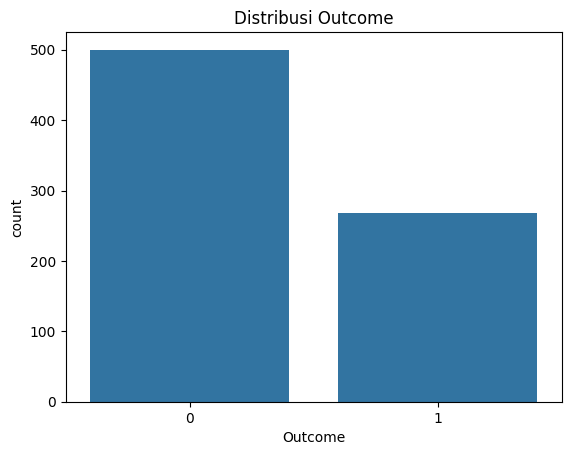

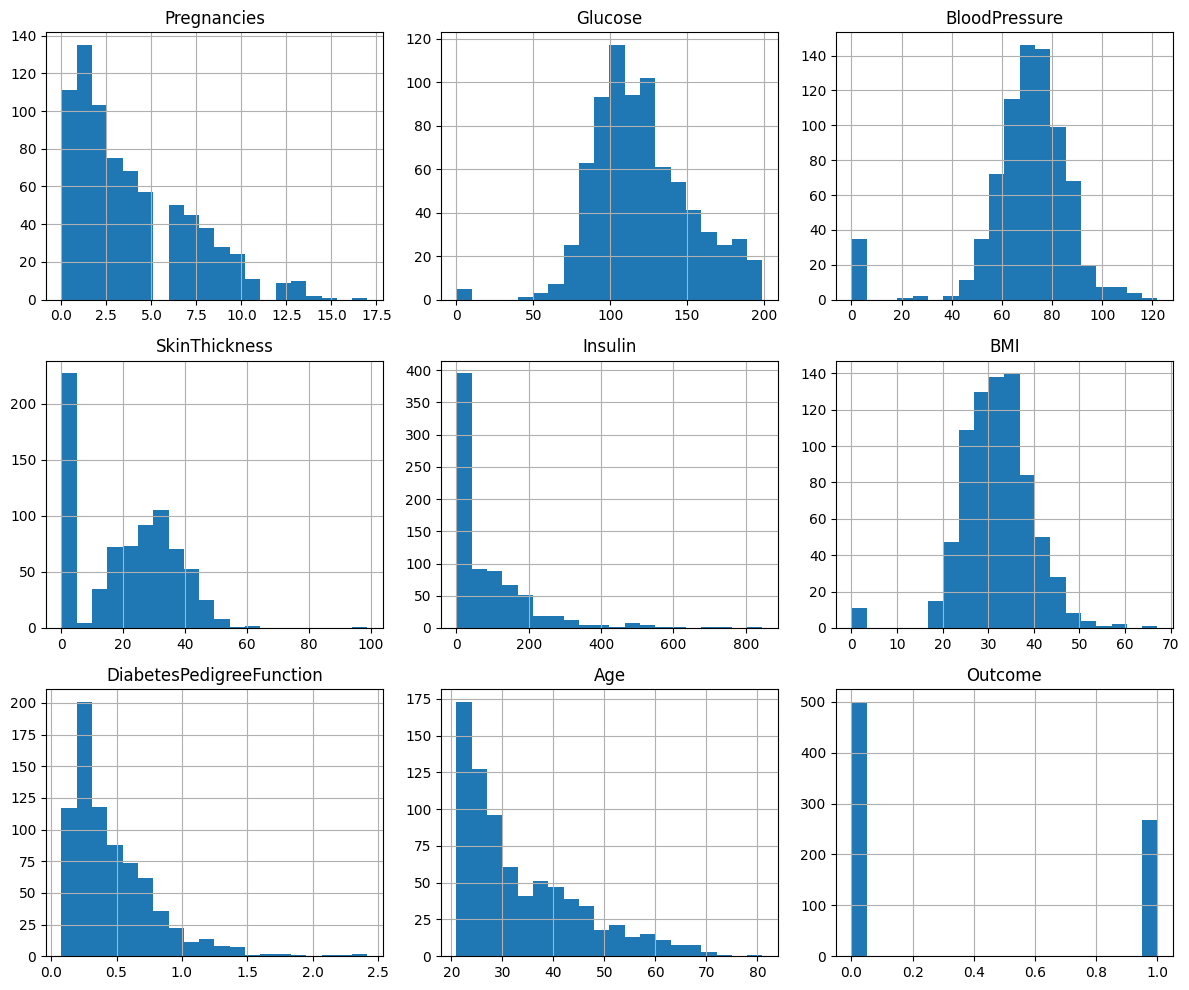

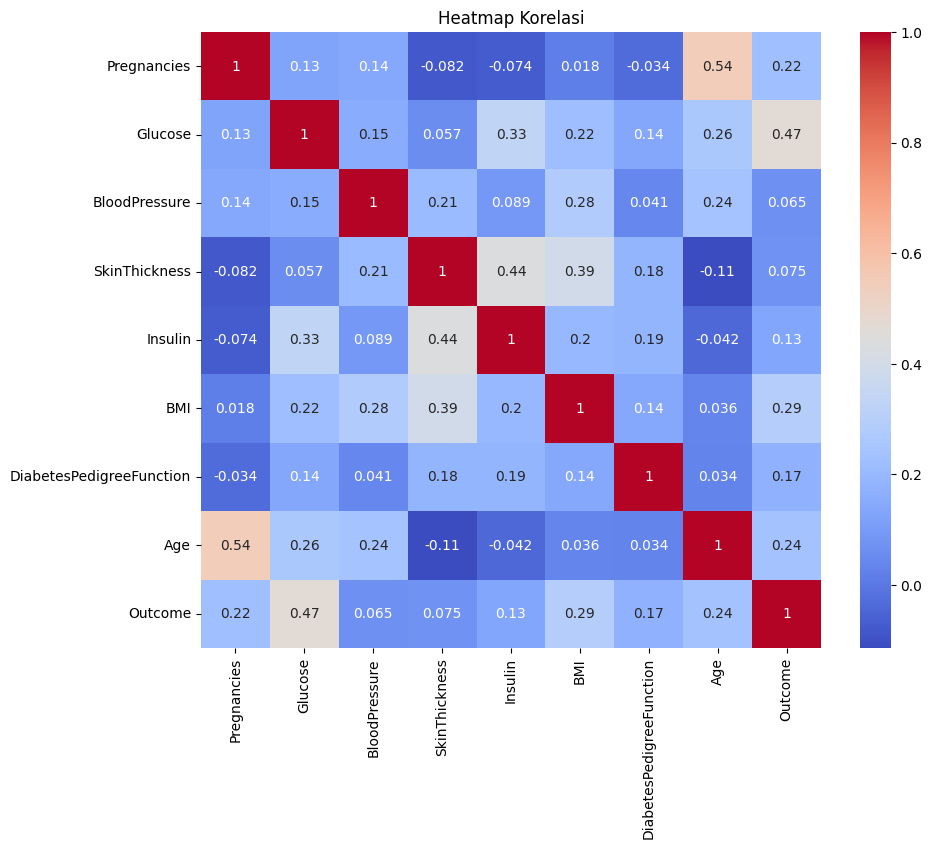

Glucose: 5 nilai 0
BloodPressure: 35 nilai 0
SkinThickness: 227 nilai 0
Insulin: 374 nilai 0
BMI: 11 nilai 0


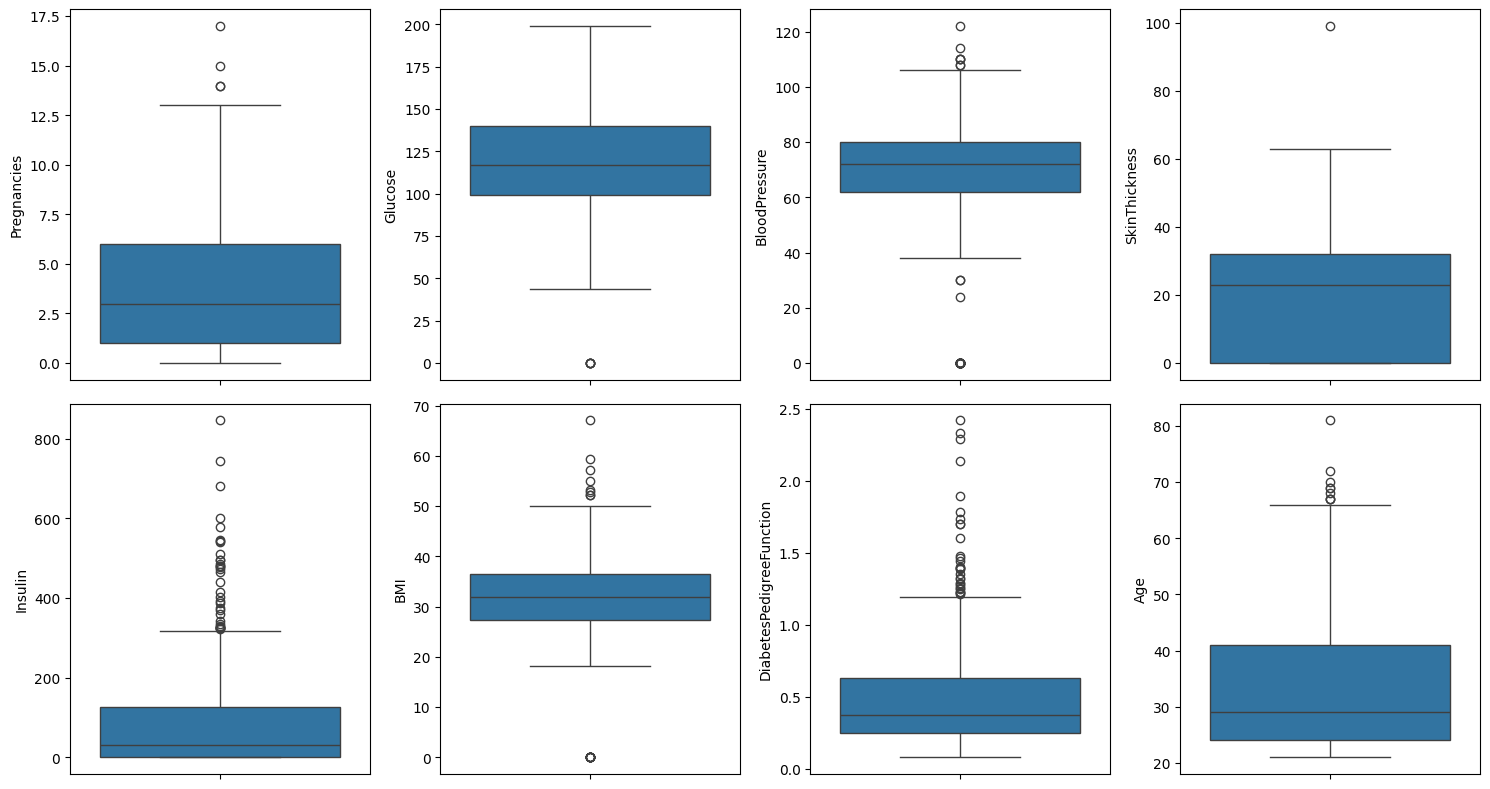

In [3]:
# Info umum
df.info()
df.describe()

# Cek missing values
df.isnull().sum()

# Distribusi target
sns.countplot(x='Outcome', data=df)
plt.title('Distribusi Outcome')
plt.show()

# Distribusi fitur
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

# Korelasi
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

# Cek nilai 0 tidak wajar (di fitur medis)
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in zero_cols:
    print(f"{col}: {(df[col]==0).sum()} nilai 0")

# Boxplot deteksi outlier
fig, axes = plt.subplots(2,4, figsize=(15,8))
for i, col in enumerate(df.columns[:-1]):
    sns.boxplot(y=df[col], ax=axes[i//4, i%4])
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

In [4]:
# 1. Ganti nilai 0 yang tidak masuk akal jadi NaN
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)

# 2. Imputasi pakai median
imputer = SimpleImputer(strategy='median')
df[zero_cols] = imputer.fit_transform(df[zero_cols])

# 3. Cek duplikat
df = df.drop_duplicates()

# 4. Penanganan outlier (capping dengan IQR)
for col in df.columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = np.where(df[col]<lower, lower, df[col])
    df[col] = np.where(df[col]>upper, upper, df[col])

# 5. Pisah fitur & target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 6. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Standarisasi
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# 8. Simpan hasil
import os
os.makedirs('diabetes_preprocessing', exist_ok=True)
X_train_scaled.to_csv('diabetes_preprocessing/X_train.csv', index=False)
X_test_scaled.to_csv('diabetes_preprocessing/X_test.csv', index=False)
y_train.to_csv('diabetes_preprocessing/y_train.csv', index=False)
y_test.to_csv('diabetes_preprocessing/y_test.csv', index=False)

print("Preprocessing selesai!")

Preprocessing selesai!
